In [1]:
# Install libraries if they are not already available in your environment
# !pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set up data visualization style
# Using 'whitegrid' helps with clear alignment and comparing data points
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

# Load the dataset
df = pd.read_csv('global_ai_tech_layoffs_2020_2026.csv')

# Display the first 5 rows to verify the data
display(df.head())

,event_id,company,industry,hq_country,hq_city,continent,founded_year,company_size_est,company_status,date_announced,...,quarter,number_laid_off,percentage_of_workforce,departments_affected,primary_reason,impact_scope,severance_info,source,stock_price_change_1wk_pct,is_ai_related_layoff
0,LO-1034,Swiggy,Food Delivery,India,Bangalore,Asia,2014,6000,Private,2020-01-04,...,Q1,722,12.0,HR / People; Legal; Product,Post-Pandemic Overhiring Correction,Global,Varies by region,News Report - The Verge,NaN,False
1,LO-1020,Oracle,Enterprise Software,United States,Austin,North America,1977,164000,Public,2020-01-06,...,Q1,6189,3.8,Legal; Business Development; Data Science / AI...,Investor Pressure,Global,6 months base salary,News Report - Bloomberg,-1.30,False
2,LO-1051,Tesla,Electric Vehicles / AI,United States,Austin,North America,2003,140000,Public,2020-01-08,...,Q1,9512,6.8,Operations,Product Shutdown,Multiple Regions,6 months base salary,News Report - CNBC,-3.89,False
3,LO-1063,Anthropic,Artificial Intelligence,United States,San Francisco,North America,2021,1500,Private,2020-01-09,...,Q1,132,8.8,Marketing; Sales; Research; Customer Support,AI Automation Replacing Roles,United States,Varies by region,Company Press Release,NaN,True
4,LO-1139,Alibaba,E-Commerce / Cloud,China,Hangzhou,Asia,1999,220000,Public,2020-01-11,...,Q1,16245,7.4,Recruiting; Supply Chain; Legal; Engineering,Merger / Acquisition,China,4 weeks base salary,News Report - TechCrunch,-5.16,False


#### **Data Cleaning & Preprocessing**

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1850 entries, 0 to 1849
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   event_id                    1850 non-null   str    
 1   company                     1850 non-null   str    
 2   industry                    1850 non-null   str    
 3   hq_country                  1850 non-null   str    
 4   hq_city                     1850 non-null   str    
 5   continent                   1850 non-null   str    
 6   founded_year                1850 non-null   int64  
 7   company_size_est            1850 non-null   int64  
 8   company_status              1850 non-null   str    
 9   date_announced              1850 non-null   str    
 10  year                        1850 non-null   int64  
 11  month                       1850 non-null   int64  
 12  quarter                     1850 non-null   str    
 13  number_laid_off             1850 non-null   

In [4]:
print("--- Initial Data Shape ---")
print(df.shape)

# 1. Handle Time Data
# Convert to datetime format for easier Time Series analysis
df['date_announced'] = pd.to_datetime(df['date_announced'])

# 2. Handle Missing Values
# The 'stock_price_change_1wk_pct' column has missing values because private companies do not have publicly traded stock.
# We create a flag to identify public companies for specific market analysis.
df['is_public'] = df['company_status'].apply(lambda x: True if x == 'Public' else False)

# 3. Standardize Text Data
# Convert the 'departments_affected' string (separated by semicolons) into a list for organizational structure analysis
df['departments_list'] = df['departments_affected'].astype(str).apply(lambda x: [d.strip() for d in x.split(';')])
df['industry'] = df['industry'].str.title().str.strip()

print("\n--- Checking missing values after processing ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

--- Initial Data Shape ---
(1850, 22)

--- Checking missing values after processing ---
stock_price_change_1wk_pct    461
dtype: int64


#### **Basic Exploratory Data Analysis (EDA)**

In [5]:
# General descriptive statistics
print("--- Descriptive Statistics for Numeric Data ---")
display(df[['number_laid_off', 'percentage_of_workforce', 'company_size_est']].describe().round(2))

# Total number of employees laid off per year
layoffs_by_year = df.groupby('year')['number_laid_off'].sum().reset_index()

# Percentage of layoff events related to AI (e.g., AI-First Strategy, Automation)
ai_impact_pct = df['is_ai_related_layoff'].value_counts(normalize=True) * 100

print("\n--- Proportion of AI-Related Layoff Events ---")
print(ai_impact_pct.round(2).astype(str) + '%')

--- Descriptive Statistics for Numeric Data ---


,number_laid_off,percentage_of_workforce,company_size_est
count,1850.00,1850.00,1850.00
mean,4452.67,6.05,76510.09
std,12196.35,4.31,185244.20
min,10.00,0.30,80.00
25%,197.25,2.80,5000.00
50%,657.50,4.90,11000.00
75%,3862.00,8.20,84900.00
max,205254.00,25.50,1540000.00



--- Proportion of AI-Related Layoff Events ---
is_ai_related_layoff
False    79.46%
True     20.54%
Name: proportion, dtype: str


#### **Data Visualization - Macro Trends & Cycles**

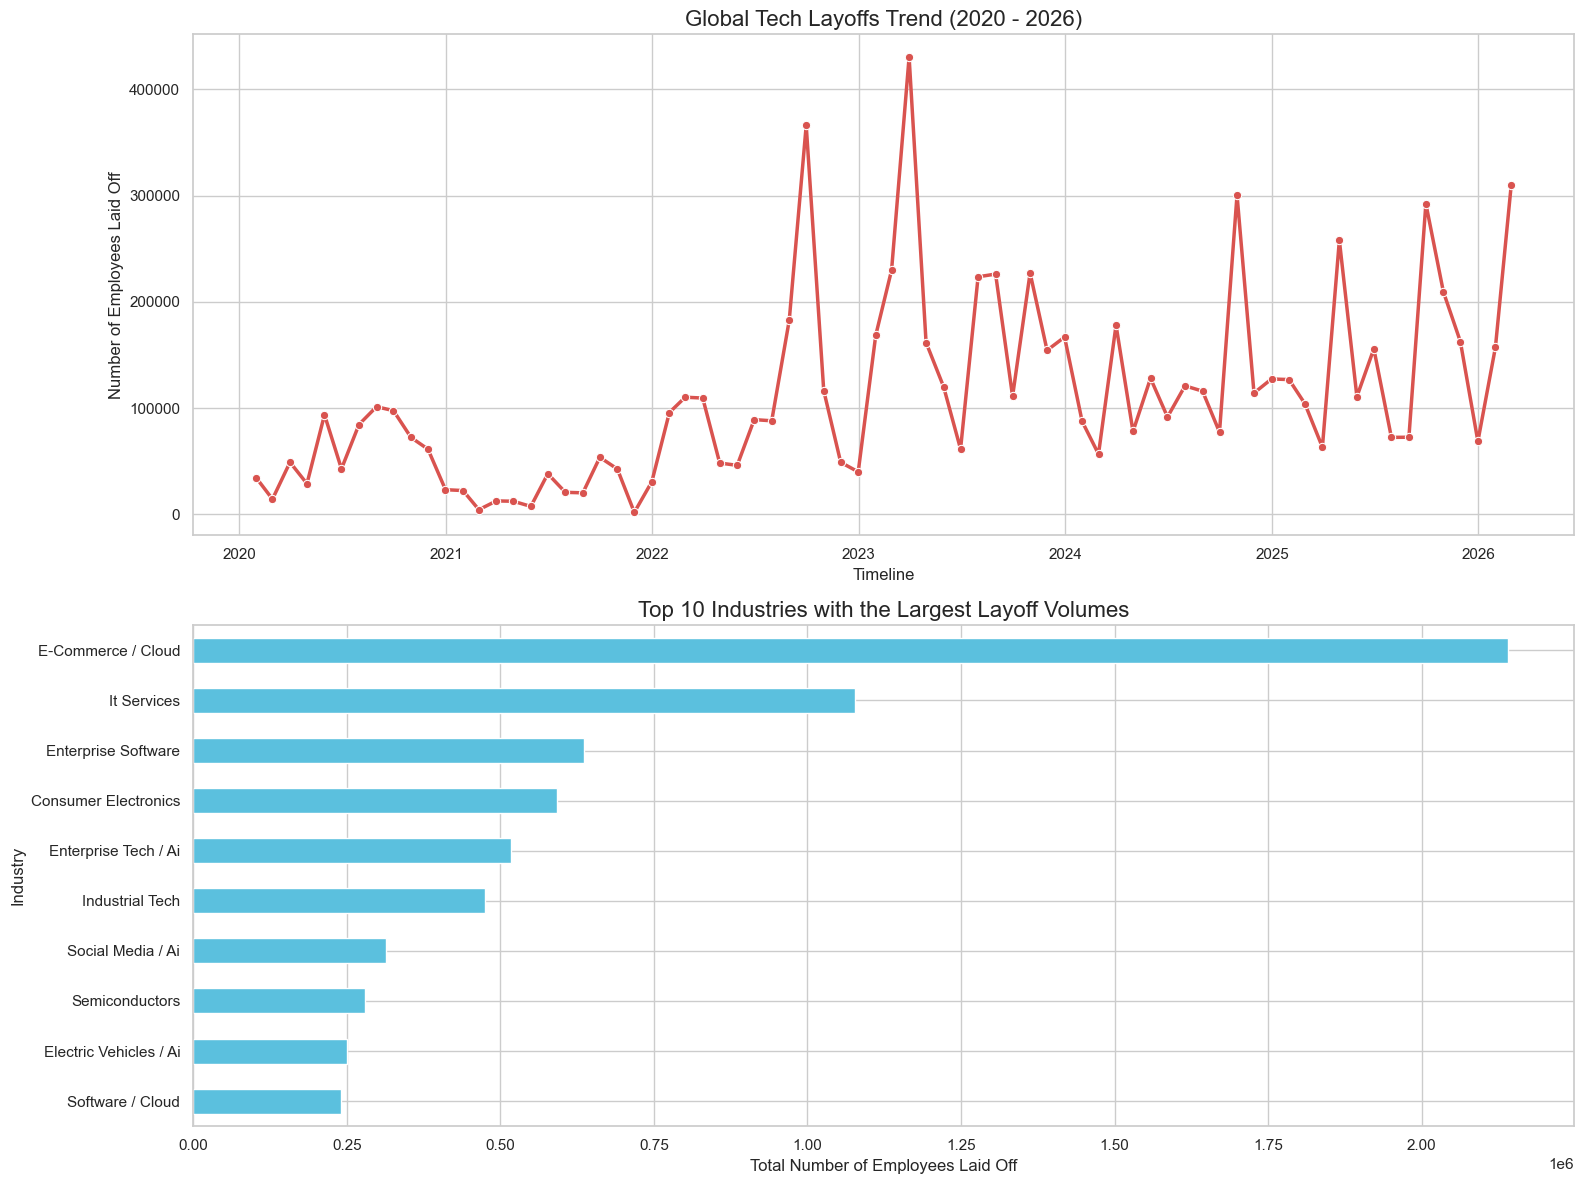

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Chart 1: Line Chart for Time Series
# A line chart is optimal for showing trends, seasonality, and disruptions over time
monthly_trend = df.set_index('date_announced').resample('ME')['number_laid_off'].sum()
sns.lineplot(x=monthly_trend.index, y=monthly_trend.values, ax=axes[0], color='#d9534f', linewidth=2.5, marker='o')
axes[0].set_title('Global Tech Layoffs Trend (2020 - 2026)')
axes[0].set_ylabel('Number of Employees Laid Off')
axes[0].set_xlabel('Timeline')

# Chart 2: Horizontal Bar Chart
# Highly effective for comparing categorical data with long labels (like industry names)
top_10_industries = df.groupby('industry')['number_laid_off'].sum().nlargest(10).sort_values()
top_10_industries.plot(kind='barh', ax=axes[1], color='#5bc0de')
axes[1].set_title('Top 10 Industries with the Largest Layoff Volumes')
axes[1].set_xlabel('Total Number of Employees Laid Off')
axes[1].set_ylabel('Industry')

plt.tight_layout()
plt.show()

* **The Layoff Rollercoaster:** Tech layoffs don't just happen randomly; they come in big waves. We can see a clear shift from the "we hired too many people during COVID" phase to companies now making very intentional, strategic cuts.
* **Who Gets Hit Hardest?:** Job losses aren't spread out evenly. A few specific industries are taking the biggest hits, showing us exactly which areas of the tech world are struggling the most and losing funding.
* **Flattening the Corporate Ladder:** Companies aren't just trying to save money—they are completely changing how they operate. Support roles like HR, recruiting, and operations are usually the first to go as businesses try to get leaner and more efficient.
* **The "AI" Factor:** We are seeing a massive shift in *why* people are losing their jobs. More and more companies are pointing directly to Artificial Intelligence as the reason for cuts, showing a real-world pivot toward an "AI-first" future.
* **How Wall Street Reacts:** Investors have a mixed reaction to layoffs. When a company cuts jobs, the stock market tries to guess if the company is secretly in deep financial trouble, or if they are just making tough choices to boost their future profits.

#### **Organizational Behavior & AI Impact Analysis**

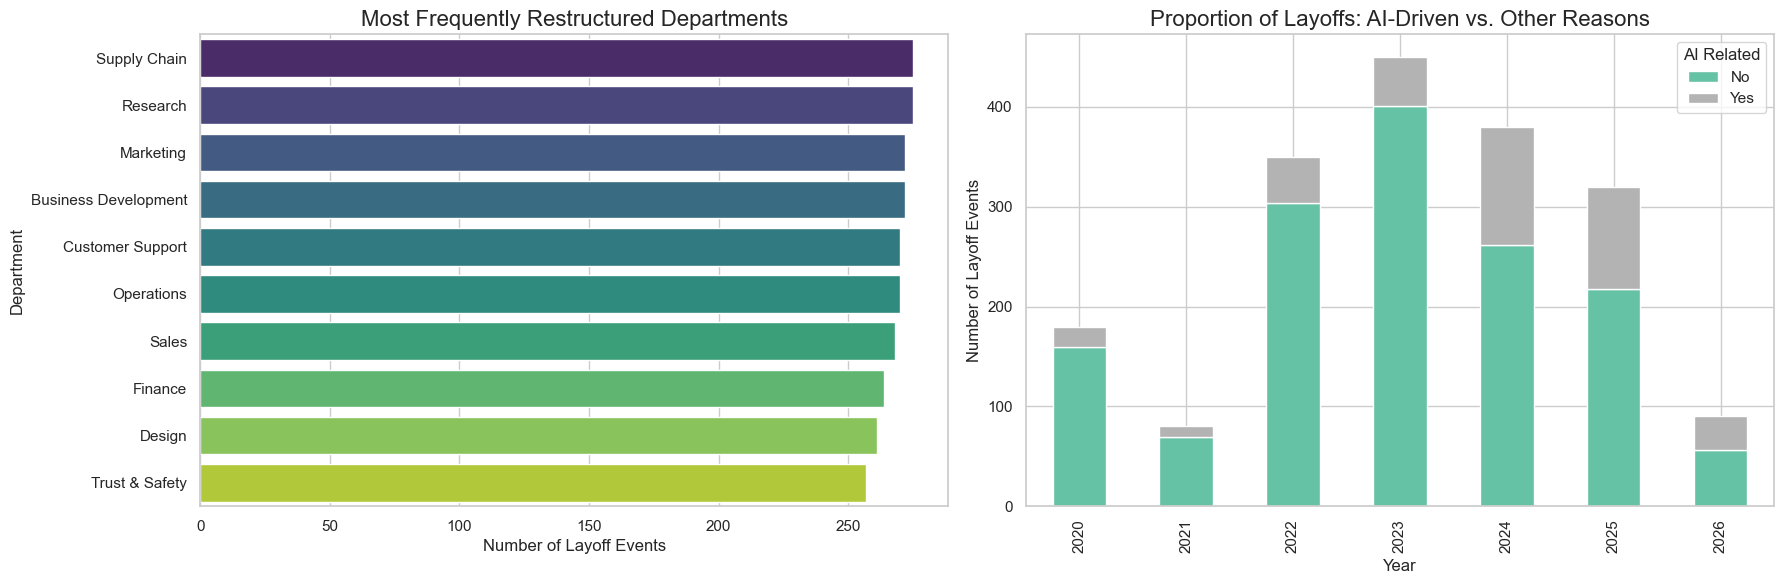

In [8]:
# Extract the affected departments to evaluate organizational resource shifts
all_departments = []
for deps in df['departments_list']:
    all_departments.extend(deps)

# Calculate the frequency of layoffs per department
dep_counts = Counter(all_departments)
df_deps = pd.DataFrame.from_dict(dep_counts, orient='index', columns=['Layoff_Events']).reset_index()
df_deps.columns = ['Department', 'Layoff_Events']
df_deps = df_deps.sort_values(by='Layoff_Events', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Chart 1: Most Impacted Departments
sns.barplot(data=df_deps, y='Department', x='Layoff_Events', ax=axes[0], palette='viridis')
axes[0].set_title('Most Frequently Restructured Departments')
axes[0].set_xlabel('Number of Layoff Events')
axes[0].set_ylabel('Department')

# Chart 2: Stacked Bar Chart for AI Impact
# Visualizes the proportion of AI-driven decisions in layoffs over the years
ai_trend = df.groupby(['year', 'is_ai_related_layoff']).size().unstack().fillna(0)
ai_trend.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
axes[1].set_title('Proportion of Layoffs: AI-Driven vs. Other Reasons')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Layoff Events')
axes[1].legend(title='AI Related', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

* **Public vs. Private Pressure:** There's a big difference in *why* companies cut jobs. Publicly traded companies often make deeper, more aggressive cuts because they have shareholders demanding quick profit turnarounds. Private startups usually make cuts simply to extend their runway and survive.
* **Culture in a Crisis (The Severance Story):** How a company handles its severance packages is a real-time test of its organizational behavior. The data reveals the stark contrast between companies that genuinely support their departing teams, and those that just treat them as a line-item expense to be erased.
* **The Global Ripple Effect:** Job cuts rarely stay contained to one city or office. What starts as a "strategic pivot" at a headquarters in Silicon Valley quickly ripples outward, completely reshaping regional teams and global operations.
* **David vs. Goliath (Company Size):** Giant tech monopolies and smaller, agile tech firms handle layoffs very differently. The tech giants tend to trim the edges to optimize their operations, while mid-sized companies might be forced to shut down entire core products just to stay afloat.

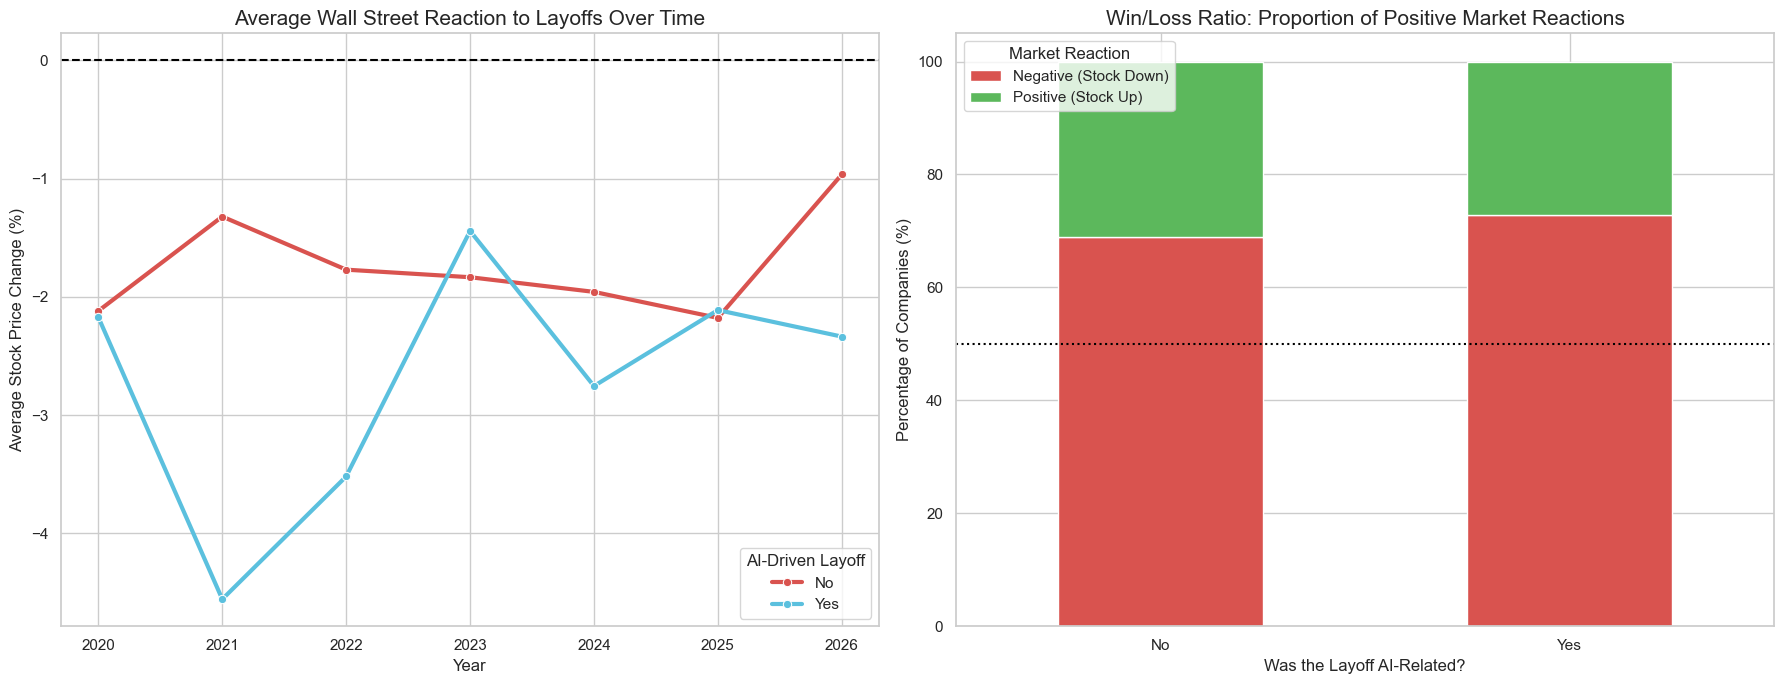

In [11]:
# ==========================================
# CÁCH TIẾP CẬN MỚI: AGGREGATED MARKET REACTION
# ==========================================

# Lọc dữ liệu các công ty Public
df_market = df.dropna(subset=['stock_price_change_1wk_pct']).copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ---------------------------------------------------------
# BIỂU ĐỒ 1: Average Market Sentiment Trend (Line Chart)
# Theo dõi sự thay đổi trong phản ứng trung bình của thị trường qua các năm
# ---------------------------------------------------------
sns.lineplot(
    data=df_market, 
    x='year', 
    y='stock_price_change_1wk_pct', 
    hue='is_ai_related_layoff',
    estimator='mean', # Chỉ lấy giá trị trung bình
    errorbar=None,    # Tắt dải nhiễu (confidence interval) để chart gọn gàng
    marker='o',
    linewidth=3,
    palette=['#d9534f', '#5bc0de'], # Đỏ (Non-AI), Xanh (AI)
    ax=axes[0]
)

axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_title('Average Wall Street Reaction to Layoffs Over Time', fontsize=15)
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Average Stock Price Change (%)', fontsize=12)
axes[0].legend(title='AI-Driven Layoff', labels=['No', 'Yes'])

# ---------------------------------------------------------
# BIỂU ĐỒ 2: Win/Loss Ratio (100% Stacked Bar Chart)
# Phân tích tỷ lệ Cổ phiếu Tăng vs Giảm
# ---------------------------------------------------------
# Phân loại cổ phiếu Tăng (Positive) hoặc Giảm (Negative)
df_market['Reaction'] = np.where(df_market['stock_price_change_1wk_pct'] > 0, 'Positive (Stock Up)', 'Negative (Stock Down)')

# Tính toán phần trăm
reaction_counts = df_market.groupby(['is_ai_related_layoff', 'Reaction']).size().unstack()
reaction_pct = reaction_counts.div(reaction_counts.sum(axis=1), axis=0) * 100

reaction_pct.plot(
    kind='bar', 
    stacked=True, 
    color=['#d9534f', '#5cb85c'], # Đỏ (Giảm), Xanh lá (Tăng)
    ax=axes[1],
    edgecolor='white'
)

axes[1].axhline(50, color='black', linestyle='dotted', linewidth=1.5) # Đường mốc 50%
axes[1].set_title('Win/Loss Ratio: Proportion of Positive Market Reactions', fontsize=15)
axes[1].set_xlabel('Was the Layoff AI-Related?', fontsize=12)
axes[1].set_ylabel('Percentage of Companies (%)', fontsize=12)
axes[1].set_xticklabels(['No', 'Yes'], rotation=0)
axes[1].legend(title='Market Reaction', loc='upper left')

plt.tight_layout()
plt.show()

The chart shows the average stock price reaction within one week after companies announce layoffs.

Key observations:

1. The overall market reaction is negative

Across all years, the average stock price change remains below 0%, indicating that layoffs are generally perceived negatively by investors.

This suggests that layoffs are often interpreted as a signal of financial difficulty or organizational restructuring.

2. AI-related layoffs triggered stronger negative reactions in some years

Between 2021 and 2022, AI-related layoffs experienced noticeably larger stock declines:

2021: around -4.5%

2022: around -3.5%

This may reflect investor uncertainty regarding AI-driven workforce restructuring or technological transitions.

3. Market reactions appear to stabilize in recent years

From 2023 onward, the gap between AI-related and non-AI layoffs becomes smaller.

This could indicate that investors are becoming more accustomed to AI-driven restructuring strategies.

The second chart analyzes the proportion of positive and negative stock reactions following layoffs.

Key insights:

1. Most market reactions are negative

For both categories:

Non-AI layoffs: about 69% of stocks decline

AI-related layoffs: about 73% decline

This indicates that layoffs are more often associated with negative short-term market sentiment.

2. AI-related layoffs show a slightly higher negative reaction rate

AI layoffs have a higher proportion of stock declines compared to traditional layoffs.

This could imply that investors may be more cautious about AI-driven workforce restructuring.

3. However, some layoffs still trigger positive reactions

Approximately:

31% of non-AI layoffs

27% of AI layoffs

result in stock price increases.

This suggests that in some cases, layoffs are interpreted as cost-cutting measures that may improve company efficiency.

### Conclusion & Strategic Directions for Further Analysis

1. **Cycles & Macro Trends:** Based on the time series analysis, we can identify the distinct "peaks" of the layoff waves. There is a clear strategic difference between the post-pandemic market corrections and the current structural shifts in the tech sector.

2. **Organizational Behavior & Restructuring:** The departmental analysis provides a clear picture of internal operational shifts. The frequent reduction in departments such as Operations, HR, and Engineering reflects a strategy of organizational flattening and core process optimization, rather than superficial cost-cutting.

3. **The Footprint of AI in Digital Strategy:** The stacked bar charts and market scatter plots demonstrate that Artificial Intelligence is no longer just a technological tool, but a core business driver. The subsequent stock price movements reflect investor expectations regarding how companies are leveraging AI to automate traditional labor and expand profit margins.